**# Business Problem/Statement**
This project analyzes retail business transaction data to identify patterns affecting sales and profitability across product categories, customer segments, and regions. The objective is to generate actionable business insights, optimize decision-making, and build predictive models that support revenue growth and profitability improvement.



In [60]:
# in this project We are going to be exploring a Superstore Sales dataset where we do data exploration, Data cleaning, Data visualization, Model training and evaluation and lot more.

**Loading Libraries**

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# import neccessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# *Understanding the Dataset*

In [63]:
#load all columns
pd.set_option('display.max_columns', None)

In [64]:
#load dataset
df = pd.read_csv('/content/drive/MyDrive/SampleSuperstore.csv')
df.head(50)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.8600,7,0.00,14.1694
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.2800,4,0.00,1.9656
7,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.1520,6,0.20,90.7152
8,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,18.5040,3,0.20,5.7825
9,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Appliances,114.9000,5,0.00,34.4700


In [65]:
# checking for shape, uniqueness, info and statistical description of dataset
shape_df = df.shape
print(shape_df)

info_df = df.info()
print(info_df)

describe_df = df.describe()
print(describe_df)

unique_df = df.nunique()
print(unique_df)


(9994, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB
None
        Postal Code         Sales     Quantity     Discount       Profit
count   9994.000000   9994.000000  9994.000000  9994.000000  9994.000000
mean   55190.379428  

In [66]:
#printing the uniqueness of ship mode and segment
print(df['Ship Mode'].unique())
print(df['Segment'].unique())
print(df['Category'].unique())
print(df['Sub-Category'].unique())
print(df['Region'].unique())

['Second Class' 'Standard Class' 'First Class' 'Same Day']
['Consumer' 'Corporate' 'Home Office']
['Furniture' 'Office Supplies' 'Technology']
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']
['South' 'West' 'Central' 'East']


# *DATA CLEANING*

Checking Missing Values, Duplicate VaLues and Inconsistency

In [67]:
# Missing values check
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [68]:
#duplicate values
df.duplicated().sum()

np.int64(17)

In [69]:
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

           Ship Mode      Segment        Country           City         State  \
568   Standard Class    Corporate  United States        Seattle    Washington   
591   Standard Class     Consumer  United States          Salem        Oregon   
935   Standard Class  Home Office  United States   Philadelphia  Pennsylvania   
950   Standard Class  Home Office  United States   Philadelphia  Pennsylvania   
1186  Standard Class    Corporate  United States        Seattle    Washington   
1479  Standard Class     Consumer  United States  San Francisco    California   
2803  Standard Class     Consumer  United States  San Francisco    California   
2807    Second Class     Consumer  United States        Seattle    Washington   
2836  Standard Class     Consumer  United States    Los Angeles    California   
3127  Standard Class     Consumer  United States  New York City      New York   
3405  Standard Class  Home Office  United States       Columbus          Ohio   
3406  Standard Class  Home O

In [70]:
# Dropping Duplicates
df= df.drop_duplicates()

In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub-Category,object
Sales,float64


In [73]:
# converting postal code to obj
df['Postal Code'] = df['Postal Code'].astype(str)
df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,object
Region,object
Category,object
Sub-Category,object
Sales,float64


In [74]:
# Checking Negative Sales/Quantity
print((df['Sales']<0).sum())
print((df['Quantity']<0).sum())

0
0


In [75]:
# Checking Profit distribution
df['Profit'].describe()

,Profit
count,9977.00000
mean,28.69013
std,234.45784
min,-6599.97800
25%,1.72620
50%,8.67100
75%,29.37200
max,8399.97600


# *Business Question Exploration*


In [76]:
# we would be grouping the features to see consistency and all.
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,741306.3133
Office Supplies,718735.2440
Technology,836154.0330


In [77]:
#grouping subcategories and category together to tell us which category sells better based on the number of subcategory sold
subcategory_sales = (
    df.groupby(['Category', 'Sub-Category'])['Quantity']
    .sum()
    .reset_index()
    .sort_values(by='Quantity', ascending=False)
)
print(subcategory_sales)


           Category Sub-Category  Quantity
6   Office Supplies      Binders      5971
10  Office Supplies        Paper      5144
2         Furniture  Furnishings      3560
16       Technology       Phones      3289
11  Office Supplies      Storage      3158
5   Office Supplies          Art      2996
13       Technology  Accessories      2976
1         Furniture       Chairs      2351
4   Office Supplies   Appliances      1729
9   Office Supplies       Labels      1396
3         Furniture       Tables      1241
8   Office Supplies    Fasteners       914
7   Office Supplies    Envelopes       906
0         Furniture    Bookcases       868
12  Office Supplies     Supplies       647
15       Technology     Machines       440
14       Technology      Copiers       234


In [78]:
grouped_data = (df.groupby(['Category', 'Sub-Category']).agg({'Sales':'sum',
                                                                'Quantity':'sum',
                                                                'Profit':'sum'}).reset_index())

print(grouped_data)

           Category Sub-Category        Sales  Quantity      Profit
0         Furniture    Bookcases  114879.9963       868  -3472.5560
1         Furniture       Chairs  327777.7610      2351  26567.1278
2         Furniture  Furnishings   91683.0240      3560  13052.7230
3         Furniture       Tables  206965.5320      1241 -17725.4811
4   Office Supplies   Appliances  107532.1610      1729  18138.0054
5   Office Supplies          Art   27107.0320      2996   6524.6118
6   Office Supplies      Binders  203409.1690      5971  30228.0003
7   Office Supplies    Envelopes   16476.4020       906   6964.1767
8   Office Supplies    Fasteners    3024.2800       914    949.5182
9   Office Supplies       Labels   12444.9120      1396   5526.3820
10  Office Supplies        Paper   78224.1420      5144  33944.2395
11  Office Supplies      Storage  223843.6080      3158  21278.8264
12  Office Supplies     Supplies   46673.5380       647  -1189.0995
13       Technology  Accessories  167380.3180   

Technology products, particularly Copiers and Phones, contribute disproportionately to profitability, while some Furniture subcategories generate losses despite strong sales performance.”

# *Visualisation of the Grouped Data*



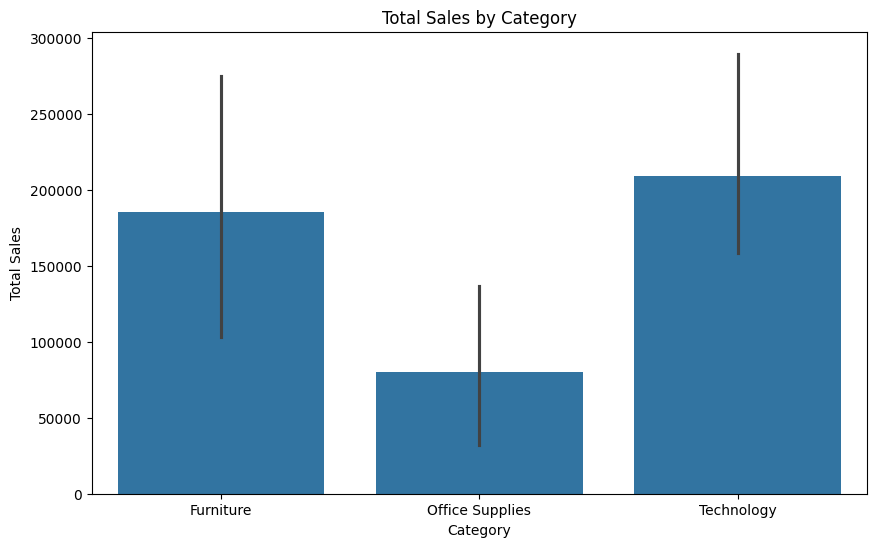

In [79]:
# visualizing the grouped data
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sales', data=grouped_data)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

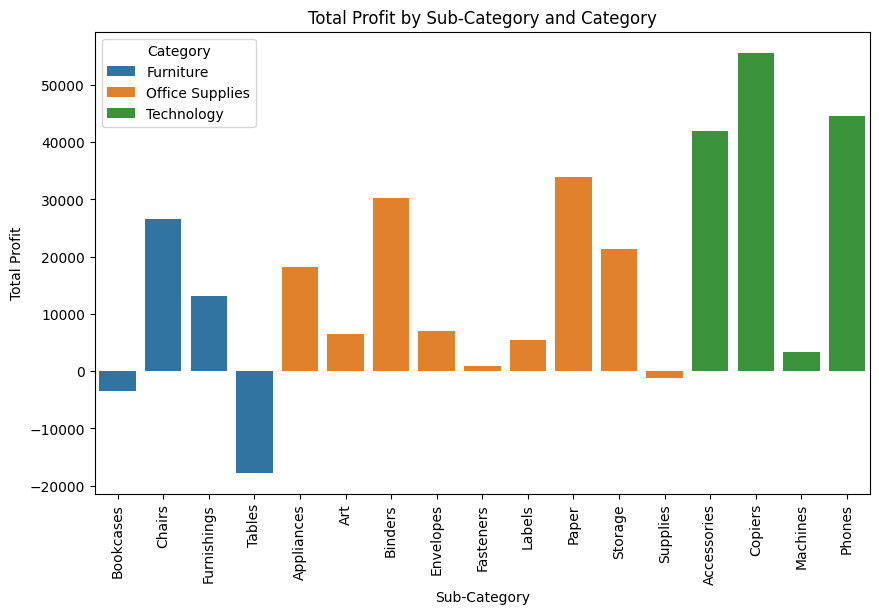

In [80]:
#analysing sub-categories and profit
plt.figure(figsize=(10, 6))
sns.barplot(x='Sub-Category', y='Profit', hue='Category', data=grouped_data)
plt.title('Total Profit by Sub-Category and Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=90)
plt.show()

The visualization shows that several Furniture subcategories, particularly Tables and Bookcases, generate negative profit despite substantial sales, indicating potential pricing, discounting, or cost-management issues. In contrast, Technology products such as Copiers and Phones contribute significantly to overall profitability, making them key profit-driving products for the business.

In [81]:
# investigating discounts
df.groupby('Sub-Category')[['Discount','Profit']].mean().sort_values(by='Discount', ascending=False)

,Discount,Profit
Sub-Category,,
Binders,0.372011,19.860710
Machines,0.306087,29.432669
Tables,0.261285,-55.565771
Bookcases,0.211140,-15.230509
Chairs,0.170244,43.198582
Appliances,0.166524,38.922758
Copiers,0.161765,817.909190
Phones,0.154556,50.073938
Furnishings,0.138494,13.653476


In [82]:
#check discount value
df['Discount'].describe()

,Discount
count,9977.000000
mean,0.156278
std,0.206455
min,0.000000
25%,0.000000
50%,0.200000
75%,0.200000
max,0.800000


The analysis shows that Binders receive the highest average discount, which may indicate aggressive pricing or promotional strategies. However, despite these discounts, Binders still maintain positive profitability. On the other hand, Copiers generate the highest profit with comparatively lower sales volume, suggesting they are high-margin products. Tables record the lowest profit, indicating that the Furniture category may be experiencing profitability challenges, potentially due to high operational costs or discount impacts. Labels have the lowest average discount, implying more stable pricing with controlled margin reduction.

# *Identifying Numerical and Categorical cols*

In [83]:
# knowing the significant cols
categorical_cols = df.select_dtypes(include=['object']).columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:\n")
print(categorical_cols)

print("\nNumerical Columns:\n")
print(numerical_cols)

Categorical Columns:

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category'],
      dtype='object')

Numerical Columns:

Index(['Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')


In [84]:
#Verify Unique Cat
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Ship Mode
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Segment
['Consumer' 'Corporate' 'Home Office']

Country
['United States']

City
['Henderson' 'Los Angeles' 'Fort Lauderdale' 'Concord' 'Seattle'
 'Fort Worth' 'Madison' 'West Jordan' 'San Francisco' 'Fremont'
 'Philadelphia' 'Orem' 'Houston' 'Richardson' 'Naperville' 'Melbourne'
 'Eagan' 'Westland' 'Dover' 'New Albany' 'New York City' 'Troy' 'Chicago'
 'Gilbert' 'Springfield' 'Jackson' 'Memphis' 'Decatur' 'Durham' 'Columbia'
 'Rochester' 'Minneapolis' 'Portland' 'Saint Paul' 'Aurora' 'Charlotte'
 'Orland Park' 'Urbandale' 'Columbus' 'Bristol' 'Wilmington' 'Bloomington'
 'Phoenix' 'Roseville' 'Independence' 'Pasadena' 'Newark' 'Franklin'
 'Scottsdale' 'San Jose' 'Edmond' 'Carlsbad' 'San Antonio' 'Monroe'
 'Fairfield' 'Grand Prairie' 'Redlands' 'Hamilton' 'Westfield' 'Akron'
 'Denver' 'Dallas' 'Whittier' 'Saginaw' 'Medina' 'Dublin' 'Detroit'
 'Tampa' 'Santa Clara' 'Lakeville' 'San Diego' 'Brentwood' 'Chapel Hill'
 'Mo

# *ANALYZE NUMERICAL FEATURESS*

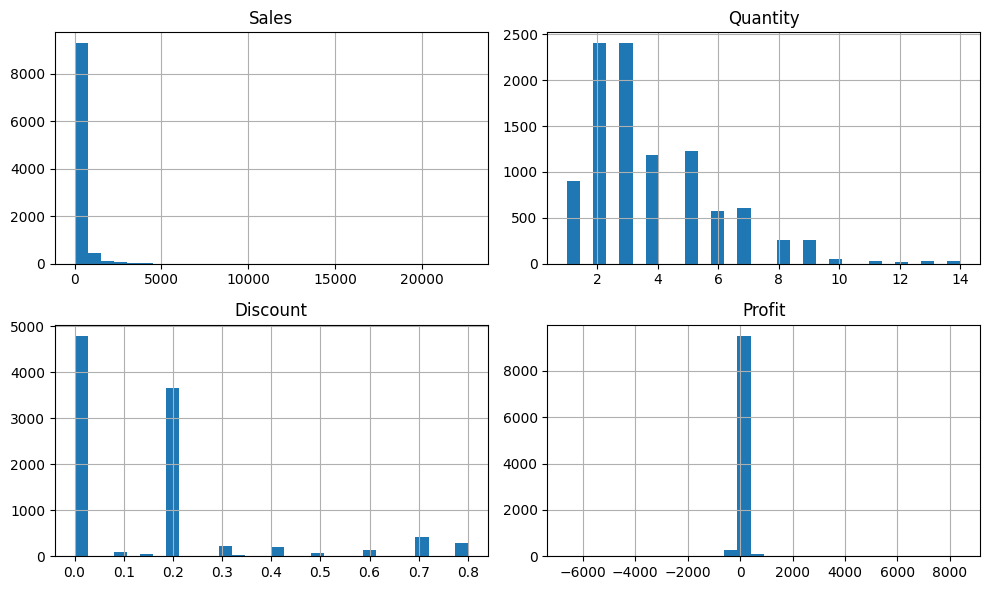

In [85]:
# Analyzing numerical features
numerical_cols= ['Sales', 'Quantity', 'Discount', 'Profit']
df[numerical_cols].hist(figsize=(10, 6),bins=30)

plt.tight_layout()

plt.show()

## *Numerical Feature Analysis*

The histogram analysis of the numerical variables reveals important patterns in the retail transaction data. Sales and Profit distributions are highly right-skewed, indicating that most transactions involve relatively small amounts, while a small number of transactions contribute exceptionally large sales and profits. This suggests that revenue generation is concentrated among a limited number of high-value purchases.

The Quantity distribution shows that customers typically purchase products in small quantities, with most transactions involving between 2 and 5 items. Large-volume purchases are relatively uncommon.

The Discount distribution appears clustered around specific values such as 0%, 20%, and higher discount ranges, suggesting the company follows structured discounting policies rather than random discount application.

Additionally, the Profit distribution contains both positive and negative values, indicating that while many transactions are profitable, some sales generate substantial losses. This may be linked to aggressive discounting, operational costs, or low-margin products and highlights areas requiring further business investigation.

Overall, the numerical distributions reveal the presence of skewness and potential outliers, which are common characteristics in real-world retail datasets and may influence subsequent statistical analysis and machine learning modeling.

### *Outlier Dectection*

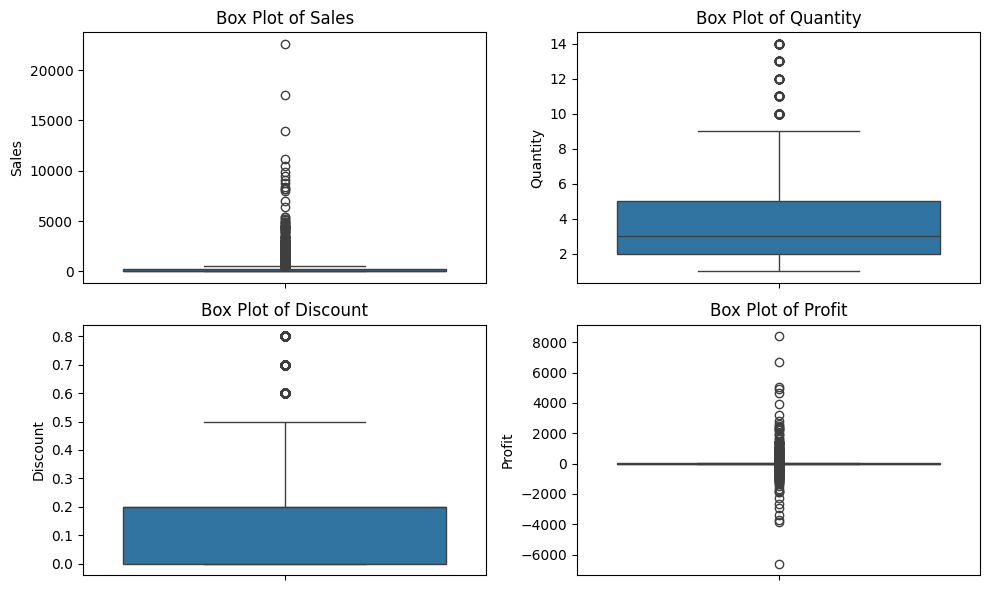

In [86]:
#detecting outliers
plt.figure(figsize=(10, 6))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

## *Outlier Analysis*

The boxplots reveal the presence of significant outliers in the Sales and Profit variables. Most transactions involve relatively low sales and profit values, while a few transactions contribute extremely high revenue or losses. This indicates a highly skewed retail distribution, which is common in real-world business datasets.

The Profit feature contains both high positive and negative outliers, suggesting that some transactions are highly profitable while others generate substantial losses. Quantity appears more stable, with most purchases concentrated around smaller order sizes.

The Discount variable shows that most discounts are low to moderate, although a few transactions receive very high discounts, which may contribute to negative profitability.

Overall, the detected outliers appear to reflect genuine business transactions rather than data entry errors, so they should be handled carefully during later modeling stages.

# *Analyzing Catergorical Data*
---
Taking each catergorical data one after another.
Checking for the three types ofanalysis
1. Univariate Caegorical Analysis - distribution
2. Bivariate Categorical Analysis - Comparison
3. MultiVariate Categorical Analysis - Relationship

In [87]:
# Category distribution
df['Category'].value_counts

<bound method IndexOpsMixin.value_counts of 0             Furniture
1             Furniture
2       Office Supplies
3             Furniture
4       Office Supplies
             ...       
9989          Furniture
9990          Furniture
9991         Technology
9992    Office Supplies
9993    Office Supplies
Name: Category, Length: 9977, dtype: object>

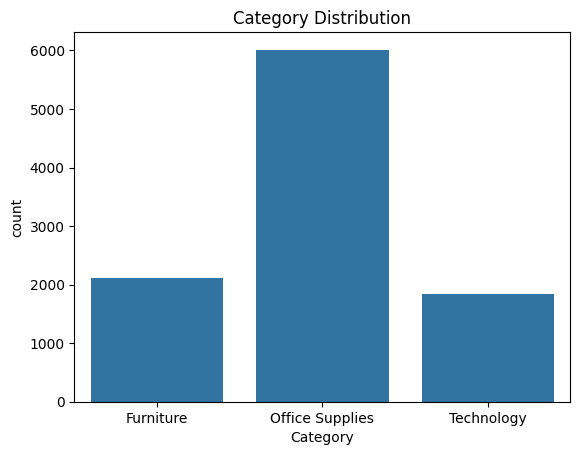

In [88]:
#visualize
sns.countplot(x='Category', data=df)
plt.title('Category Distribution')
plt.show()

In [89]:
#Analysing Numerical and categorical
category_performance = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

print(category_performance)

          Category        Sales       Profit
0        Furniture  741306.3133   18421.8137
1  Office Supplies  718735.2440  122364.6608
2       Technology  836154.0330  145454.9481


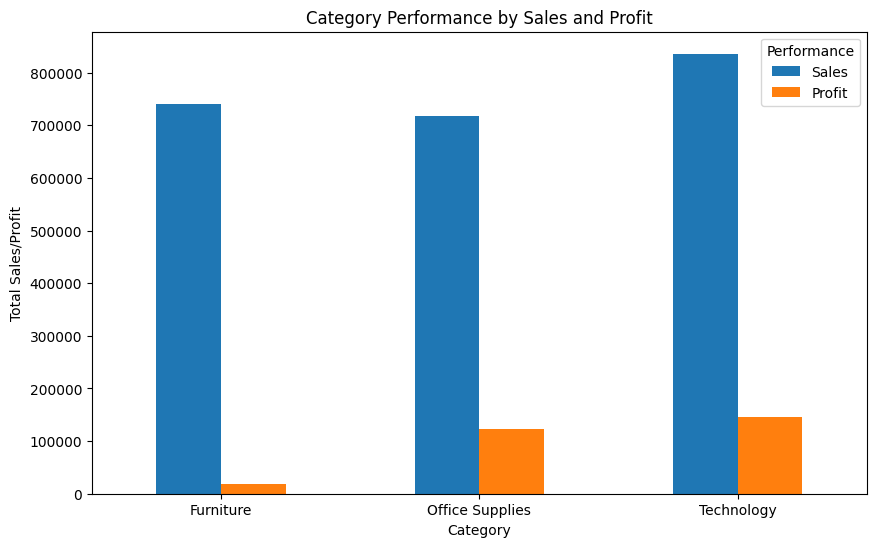

In [90]:
# visualizing category perfomance
category_performance.plot(
    kind='bar',
    figsize=(10, 6),
    x='Category'
)
plt.title('Category Performance by Sales and Profit')
plt.ylabel('Total Sales/Profit')
plt.xticks(rotation=0)
plt.legend(title='Performance')
plt.show()

### *Refined Business Insights*
**1. Technology**

Technology demonstrates the strongest profitability despite having lower transaction frequency. This suggests that Technology products operate with higher margins and contribute significantly to the company’s overall profit performance.

**2. Furniture**

Furniture generates substantial sales revenue but comparatively low profitability. This indicates possible issues related to:
* high operational costs,
* excessive discounting,
* or low profit margins within certain furniture subcategories.

**3. Office Supplies**

Office Supplies contributes the highest transaction volume and maintains relatively stable profitability. Although its profit margins are lower than Technology, the category benefits from consistent customer demand and recurring purchases.

In [91]:
# DeepDive Into Funiture Losses
funiture_losses = df[df['Category'] == 'Furniture']
furniture_summary = (
    funiture_losses.groupby('Sub-Category')[['Profit', 'Sales']].sum().sort_values(by='Profit').reset_index()
)
print(furniture_summary)
#

  Sub-Category      Profit        Sales
0       Tables -17725.4811  206965.5320
1    Bookcases  -3472.5560  114879.9963
2  Furnishings  13052.7230   91683.0240
3       Chairs  26567.1278  327777.7610


The analysis reveals that Tables contribute significantly to sales revenue within the Furniture category, yet they generate the highest losses among all furniture subcategories. This suggests that strong sales performance alone does not guarantee profitability. The negative profit margins may be driven by aggressive discounting, high operational costs, or inefficient pricing strategies, indicating that Tables require immediate business attention and profitability optimization.

In [92]:
# why does table losses money?
tables_data = df[df['Sub-Category']=='Tables']
tables_data[['Sales','Profit','Discount']].describe()

,Sales,Profit,Discount
count,319.000000,319.000000,319.000000
mean,648.794771,-55.565771,0.261285
std,615.774655,230.565006,0.169622
min,24.368000,-1862.312400,0.000000
25%,244.006000,-122.829300,0.200000
50%,447.840000,-31.372200,0.300000
75%,872.170000,33.851700,0.400000
max,4297.644000,629.010000,0.500000


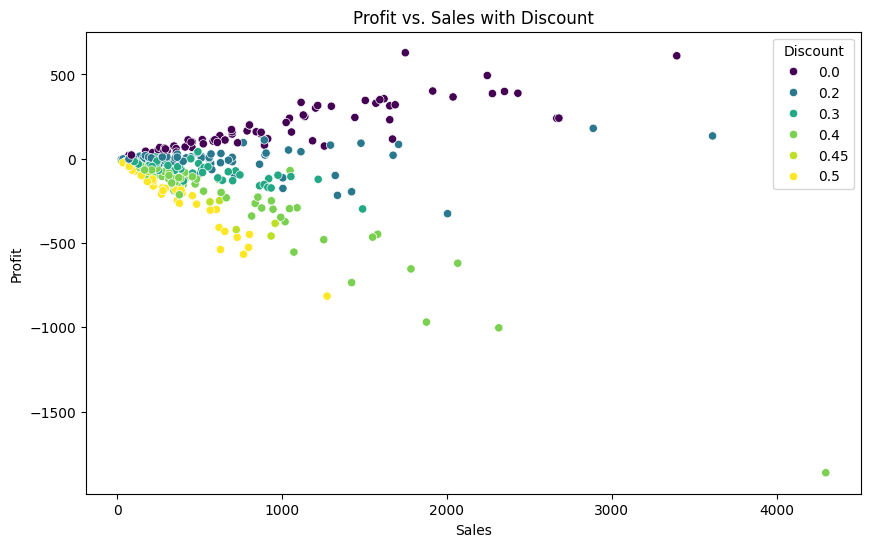

In [93]:
# visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tables_data, x='Sales', y='Profit', hue='Discount', palette='viridis')
plt.title('Profit vs. Sales with Discount')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()
#

The analysis reveals that Table transactions receiving discounts are significantly more likely to generate losses, while transactions without discounts consistently remain profitable. Higher discount levels correspond with increasingly negative profit margins, suggesting that aggressive discounting is a major contributor to the poor profitability performance of the Tables subcategory.

In [94]:
#regional analysis
regional_performance = (
    df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
)
print(regional_performance)

    Region        Sales       Profit
0  Central  500782.8528   39655.8752
1     East  678435.1960   91506.3092
2    South  391721.9050   46749.4303
3     West  725255.6365  108329.8079


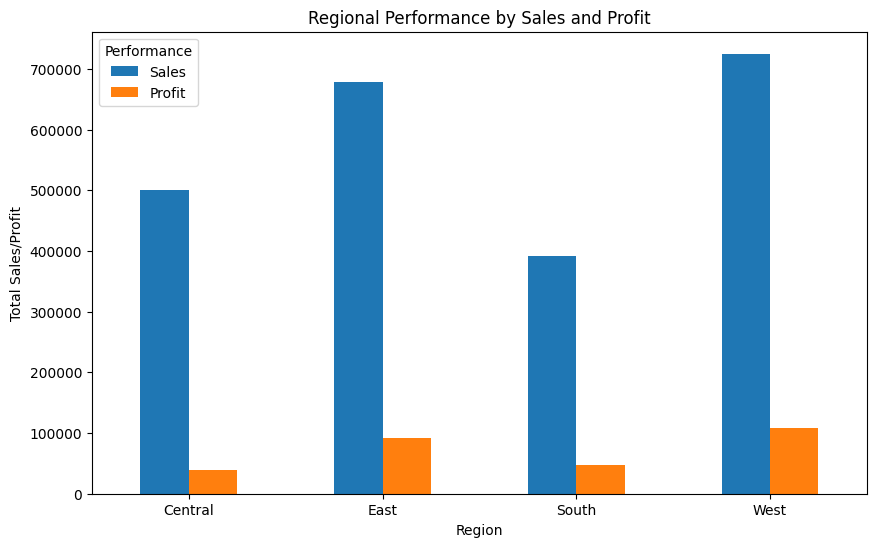

In [95]:
regional_performance.plot(
    kind='bar',
    figsize=(10, 6),
    x='Region'
)
plt.title('Regional Performance by Sales and Profit')
plt.ylabel('Total Sales/Profit')
plt.xticks(rotation=0)
plt.legend(title='Performance')
plt.show()

In [96]:
# Segment analysis
segment_performance = (
    df.groupby('Segment')[['Sales', 'Profit']].sum().reset_index()
)
print(segment_performance)

       Segment         Sales       Profit
0     Consumer  1.160833e+06  134007.4413
1    Corporate  7.060701e+05   91954.9798
2  Home Office  4.292927e+05   60279.0015


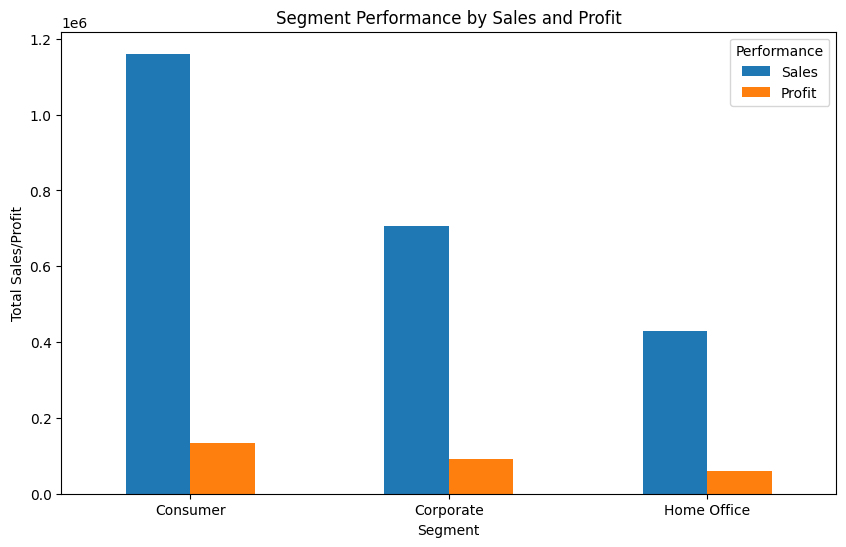

In [97]:
#visualization
segment_performance.plot(
    kind='bar',
    figsize=(10, 6),
    x='Segment'
)
plt.title('Segment Performance by Sales and Profit')
plt.ylabel('Total Sales/Profit')
plt.xticks(rotation=0)
plt.legend(title='Performance')
plt.show()

In [98]:
#shipping mode analysis
shipping_mode_performance = (
    df.groupby('Ship Mode')[['Sales', 'Profit']].sum().reset_index()
)
print(shipping_mode_performance)

        Ship Mode         Sales       Profit
0     First Class  3.513805e+05   48953.6561
1        Same Day  1.283217e+05   15871.8869
2    Second Class  4.591770e+05   57446.6516
3  Standard Class  1.357316e+06  163969.2280


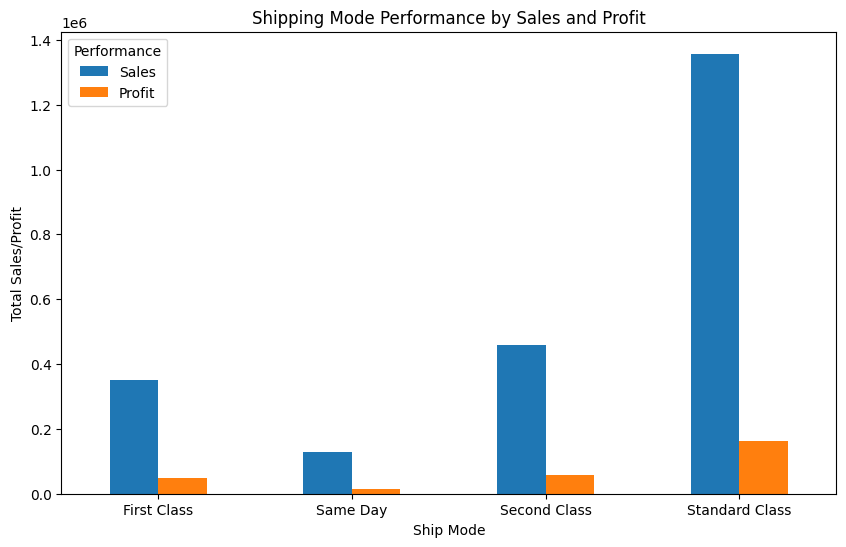

In [99]:
#visualization
shipping_mode_performance.plot(
    kind='bar',
    figsize=(10, 6),
    x='Ship Mode'
)
plt.title('Shipping Mode Performance by Sales and Profit')
plt.ylabel('Total Sales/Profit')
plt.xticks(rotation=0)
plt.legend(title='Performance')
plt.show()
#

In [100]:
#correclation and relationship analysis
correlation = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
print(correlation)

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200722 -0.028311  0.479067
Quantity  0.200722  1.000000  0.008678  0.066211
Discount -0.028311  0.008678  1.000000 -0.219662
Profit    0.479067  0.066211 -0.219662  1.000000


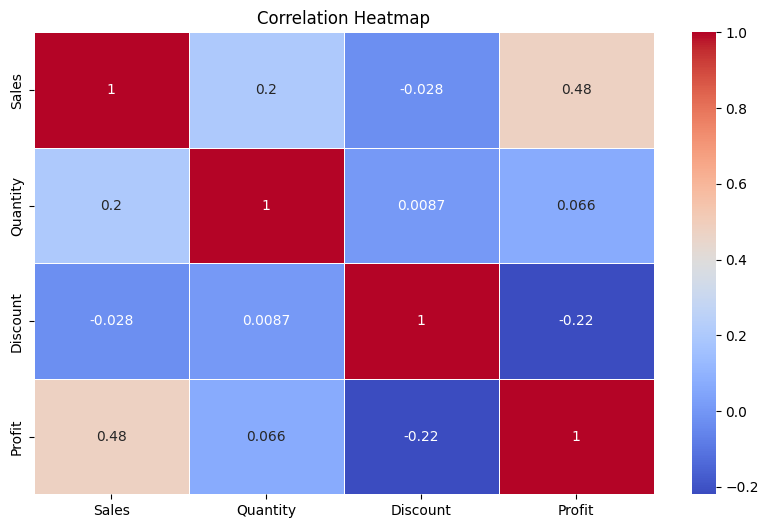

In [101]:
# Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


In [102]:
#region and category
region_category_performance = (
    df.groupby(['Region', 'Category'])['Profit'].sum().reset_index()
)
print(region_category_performance)
#

     Region         Category      Profit
0   Central        Furniture  -2906.1467
1   Central  Office Supplies   8864.5899
2   Central       Technology  33697.4320
3      East        Furniture   3058.2246
4      East  Office Supplies  40986.0495
5      East       Technology  47462.0351
6     South        Furniture   6771.2061
7     South  Office Supplies  19986.3928
8     South       Technology  19991.8314
9      West        Furniture  11498.5297
10     West  Office Supplies  52527.6286
11     West       Technology  44303.6496


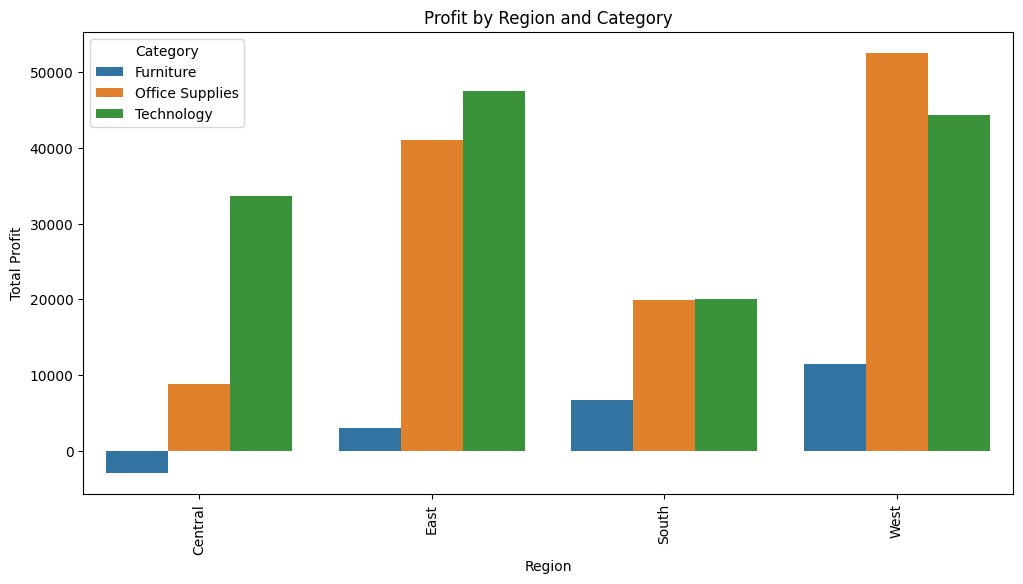

In [103]:
#visualize
plt.figure(figsize=(12, 6))
sns.barplot(x='Region', y='Profit', hue='Category', data=region_category_performance)
plt.title('Profit by Region and Category')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=90)
plt.legend(title='Category')
plt.show()


The analysis reveals that the Furniture category performs particularly poorly in the Central region, where profitability falls significantly below zero. This suggests that regional factors may be intensifying the profitability challenges already observed within Furniture products. The findings indicate a need for region-specific business strategies, such as pricing optimization, discount control, or operational cost review within the Central market.

In [104]:
#deep dive into why there's low output of profit on funiture in the central region
central_furniture = df[(df['Region'] == 'Central') & (df['Category'] == 'Furniture')]
central_furniture_summary = (
    central_furniture.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values(by='Profit').reset_index()
)
print(central_furniture_summary)


  Sub-Category       Sales     Profit
0  Furnishings  15254.3700 -3906.2168
1       Tables  39154.9710 -3559.6504
2    Bookcases  24157.1768 -1997.9043
3       Chairs  84840.6760  6557.6248


In [105]:
# Comparing average discount, discounting could be the cause of the losses in these products
central_furniture[['Discount']].describe()

,Discount
count,480.000000
mean,0.298000
std,0.237853
min,0.000000
25%,0.000000
50%,0.300000
75%,0.600000
max,0.600000


In [106]:
central_furniture.groupby('Sub-Category')[['Discount']].mean().sort_values(by='Discount', ascending=False)


,Discount
Sub-Category,
Furnishings,0.403902
Tables,0.262500
Bookcases,0.232800
Chairs,0.194118


“The findings suggest that aggressive discounting may be used to stimulate demand in the Central region, potentially due to weaker market demand, competitive pressure, affordability concerns, or regional sales strategies.”

# *KEY BUSINESS INSIGHT*
1. Technology Is the Most Profitable Category

Despite lower transaction frequency, Technology products generate the highest overall profit, indicating strong margins and high-value transactions.

2. Furniture Experiences Major Profitability Issues

Furniture generates high sales revenue but comparatively low profit, suggesting operational inefficiencies or weak pricing strategies.

3. Tables Are a Major Source of Losses

Tables produce some of the highest sales within Furniture while simultaneously generating significant losses, indicating poor profitability management.

4. Discounts Negatively Affect Profitability

Higher discounts are strongly associated with lower profit margins, particularly within Furniture products such as Tables and Furnishings.

5. Central Region Shows Severe Furniture Losses

Furniture profitability is especially poor in the Central region, where multiple subcategories generate negative profit, suggesting region-specific business challenges.

6. Consumer Segment Drives Overall Business Performance

The Consumer segment contributes the highest sales and profit, making it the The company’s strongest customer group.

**Business Recommendations**
1. Reduce Aggressive Discounting on Furniture Products

The analysis shows that high discounts, particularly on Tables, Furnishings, and Bookcases, are strongly associated with negative profitability. The company should review its discounting strategy to ensure discounts do not excessively erode profit margins.

2. Investigate Furniture Performance in the Central Region

Furniture products perform especially poorly in the Central region. The company should conduct further market analysis to determine whether the losses are caused by:

* weak regional demand,
* pricing pressure,
* operational costs,
* or customer affordability concerns.

3. Prioritize High-Margin Technology Products

Technology products generate the strongest profitability despite lower transaction frequency. Increasing marketing efforts and inventory focus on profitable Technology products such as Copiers and Phones may improve overall business performance.

4. Optimize Loss-Making Subcategories

Subcategories such as Tables and Bookcases should undergo profitability review. The company may need to:

* adjust pricing,
* reduce discounts,
* renegotiate supplier costs,
* or redesign promotional strategies.

5. Strengthen Consumer Customer Retention

The Consumer segment contributes the highest sales and profit. Retention campaigns, loyalty programs, and targeted promotions may help maintain and expand this valuable customer base.

6. Review Regional Business Strategies

Since regional performance varies significantly, the company should consider region-specific strategies rather than applying uniform pricing and promotional policies across all markets.

In [107]:
df.to_csv('cleaned_superstore.csv', index=False)